# 07 — Optimizers and the Complete End-to-End Training Loop (PyTorch)


> **Learning contract.** Every code cell is preceded by an explanation of what the code does, why the operation exists mathematically, what tensor/array shapes are expected, and what production or business failure it prevents. Run the notebooks in numerical order in a fresh Conda environment.


Training is repeated parameter estimation: sample a mini-batch, forward propagate, compute loss, backpropagate gradients, convert gradients into an optimizer update, then validate after the epoch. **Gradient is not the same thing as update.** SGD uses the current gradient directly; Momentum smooths updates with velocity; Adam combines moving averages of first and second moments.

The test split is deliberately absent from model-selection decisions in this notebook.


## Code walkthrough — complete PyTorch training pipeline
This is the core executable training code. Read it line by line. The training path shuffles mini-batches and updates parameters; the validation path performs forward-only evaluation. Metrics are collected every epoch and the trained artifact is persisted for later inference notebooks.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
from pathlib import Path
import urllib.request
import numpy as np
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
ARTIFACT_DIR = ROOT / "artifacts"
DATA_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR.mkdir(exist_ok=True)
MNIST_PATH = DATA_DIR / "mnist.npz"
MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"


def load_official_mnist():
    if not MNIST_PATH.exists():
        print("Downloading official MNIST archive to", MNIST_PATH)
        urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)
    with np.load(MNIST_PATH) as data:
        return (data["x_train"], data["y_train"], data["x_test"], data["y_test"])


def balanced_subset(x, y, per_class, seed=SEED):
    rng = np.random.default_rng(seed)
    selected = []
    for cls in range(10):
        candidates = np.flatnonzero(y == cls)
        selected.extend(rng.choice(candidates, size=per_class, replace=False))
    selected = np.asarray(selected)
    rng.shuffle(selected)
    return (x[selected], y[selected])


def prepare_splits():
    x_train_raw, y_train_raw, x_test_raw, y_test_raw = load_official_mnist()
    x_dev, y_dev = balanced_subset(x_train_raw, y_train_raw, per_class=600)
    x_test, y_test = balanced_subset(
        x_test_raw, y_test_raw, per_class=100, seed=SEED + 1
    )
    x_train, x_val, y_train, y_val = train_test_split(
        x_dev, y_dev, test_size=1000, random_state=SEED, stratify=y_dev
    )

    def transform(x):
        return x.reshape(len(x), -1).astype("float32") / 255.0

    return (
        transform(x_train),
        y_train,
        transform(x_val),
        y_val,
        transform(x_test),
        y_test,
    )


class MNISTMLP(nn.Module):

    def __init__(self, hidden=64):
        super().__init__()
        self.fc1 = nn.Linear(784, hidden)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden, 10)
        nn.init.kaiming_normal_(self.fc1.weight, nonlinearity="relu")
        nn.init.zeros_(self.fc1.bias)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.zeros_(self.fc2.bias)

    def forward(self, x):
        z1 = self.fc1(x)
        a1 = self.act(z1)
        logits = self.fc2(a1)
        return logits


model = MNISTMLP(hidden=64)
X_train, y_train, X_val, y_val, X_test, y_test = prepare_splits()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train).long())
val_ds = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val).long())
train_loader = DataLoader(
    train_ds,
    batch_size=128,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
model = MNISTMLP(hidden=64).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)


def run_epoch(loader, training):
    model.train(training)
    total_loss = total_correct = total = 0
    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for xb, yb in loader:
            xb, yb = (xb.to(device), yb.to(device))
            if training:
                optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(xb)
            total_correct += (logits.argmax(1) == yb).sum().item()
            total += len(xb)
    return (total_loss / total, total_correct / total)


history = []
for epoch in range(1, 6):
    train_loss, train_acc = run_epoch(train_loader, True)
    val_loss, val_acc = run_epoch(val_loader, False)
    history.append((train_loss, train_acc, val_loss, val_acc))
    print(
        f"epoch={epoch} train_loss={train_loss:.4f} train_acc={train_acc:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )
torch.save(model.state_dict(), ARTIFACT_DIR / "mnist_pytorch_mlp.pt")

epoch=1 train_loss=1.2982 train_acc=0.6726 val_loss=0.6723 val_acc=0.8330
epoch=2 train_loss=0.5467 train_acc=0.8666 val_loss=0.4471 val_acc=0.8890
epoch=3 train_loss=0.4100 train_acc=0.8976 val_loss=0.3918 val_acc=0.8960
epoch=4 train_loss=0.3563 train_acc=0.9086 val_loss=0.3515 val_acc=0.9020


epoch=5 train_loss=0.3167 train_acc=0.9164 val_loss=0.3226 val_acc=0.9100


## Code walkthrough — visualize optimization instead of reading only the final accuracy
Loss should generally decrease while validation accuracy improves. A widening train/validation gap is an overfitting signal. Flat loss can indicate poor learning rate, bad initialization, insufficient capacity, preprocessing bugs or gradient problems.


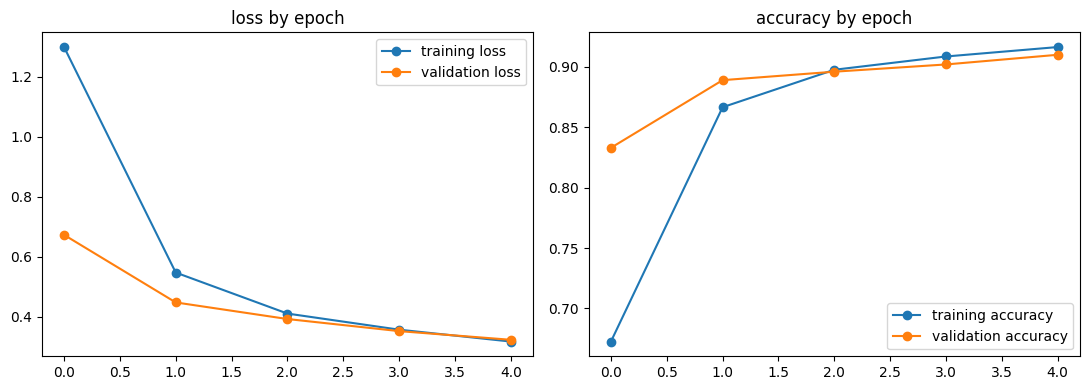

In [2]:
hist = np.asarray(history, dtype=float)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist[:, 0], marker="o", label="training loss")
if hist.shape[1] == 4:
    axes[0].plot(hist[:, 2], marker="o", label="validation loss")
axes[0].legend()
axes[0].set_title("loss by epoch")
axes[1].plot(hist[:, 1], marker="o", label="training accuracy")
axes[1].plot(hist[:, -1], marker="o", label="validation accuracy")
axes[1].legend()
axes[1].set_title("accuracy by epoch")
plt.tight_layout()
plt.show()

## Production engineering checklist
A production training job also records code commit, dataset version, split IDs, hyperparameters, seed, environment lock, metrics, artifact checksum and run timestamp. The notebook teaches the mechanics; an MLOps system automates provenance and promotion.


### Interactive Plotly lab — clone + run locally

## Interactive 3D loss landscape and optimizer trajectories

> **GitHub vs local behavior.** GitHub keeps the committed static plots, tables, metrics and explanations visible. **Clone this branch, create `environment.yml`, open the notebook in VS Code/Jupyter, select the Conda kernel, and run the cell below for full Plotly interactivity**: hover, zoom, pan, 3D rotation, legend selection, sliders and animation.

Rotate the surface, hover exact loss values and compare learning rates. This deliberately low-dimensional landscape exposes how step size changes convergence, overshoot and oscillation.

**Production/business interpretation.** The interaction is an inspection instrument, not decoration: change or inspect a technical quantity and connect it to model behavior, operational risk or downstream decision quality.


In [3]:
import os
import numpy as np
import plotly.graph_objects as go

w_axis = np.linspace(-3, 4, 90); b_axis = np.linspace(-3, 2, 90); W, B = np.meshgrid(w_axis, b_axis); LOSS = (W - 1.5) ** 2 + 0.5 * (B + 0.5) ** 2
def path(lr, steps=18):
    w, b, rows = -2.5, 1.8, []
    for step in range(steps):
        loss = (w - 1.5) ** 2 + 0.5 * (b + 0.5) ** 2; rows.append((w, b, loss, step)); w -= lr * 2 * (w - 1.5); b -= lr * (b + 0.5)
    return rows
fig = go.Figure(data=[go.Surface(x=W, y=B, z=LOSS, opacity=0.72, colorscale="Viridis", hovertemplate="w=%{x:.2f}<br>b=%{y:.2f}<br>loss=%{z:.3f}<extra></extra>")])
for lr in [0.05, 0.2, 0.8]:
    rows = path(lr); fig.add_trace(go.Scatter3d(x=[r[0] for r in rows], y=[r[1] for r in rows], z=[r[2] for r in rows], mode="lines+markers", name=f"learning rate={lr}", text=[f"step={r[3]}" for r in rows], hovertemplate="%{text}<br>w=%{x:.3f}<br>b=%{y:.3f}<br>loss=%{z:.4f}<extra></extra>"))
fig.update_layout(title="Interactive loss landscape + gradient-descent trajectories", scene=dict(xaxis_title="weight w", yaxis_title="bias b", zaxis_title="loss"))
if os.getenv("GITHUB_ACTIONS") == "true":
    print("Interactive 3D optimization landscape built. Run locally to rotate and compare learning rates.")
else:
    fig.show(renderer="plotly_mimetype")


Interactive 3D optimization landscape built. Run locally to rotate and compare learning rates.
